-Integrantes:
- Jose David Román Restrepo
- Wendy Sofía Ortega Castro
- Juan PabloCuadro Calume

# Regresióon Lineal

## Métodos de Regresión
Estos métodos buscan explicar o predecir una variable a partir de otra u otras variables encontrando relaciones matemáticas lineales. 

### Definiciones:
- *__Variable independiente__*: Variables que serán usadas para describir a la variable dependiente.
- *__Variable dependiente__*: Variable que será predicha o explicada por medio del modelo de regresión.
- *__Coeficientes del modelo__*: Valores numéricos que acompañan la variable independiente. Generalmente se denotan con la letra $\beta$ 
- *__Record__*: En datos estructurados en tablas (DataFrames) un record, corresponde a una fila.
- *__Residuos__*: Son el resultado de la diferencia entre el valor de la variable independiente predicha y la variable independiente real.

    $Residuo = y_{real} - y_{predicha}$

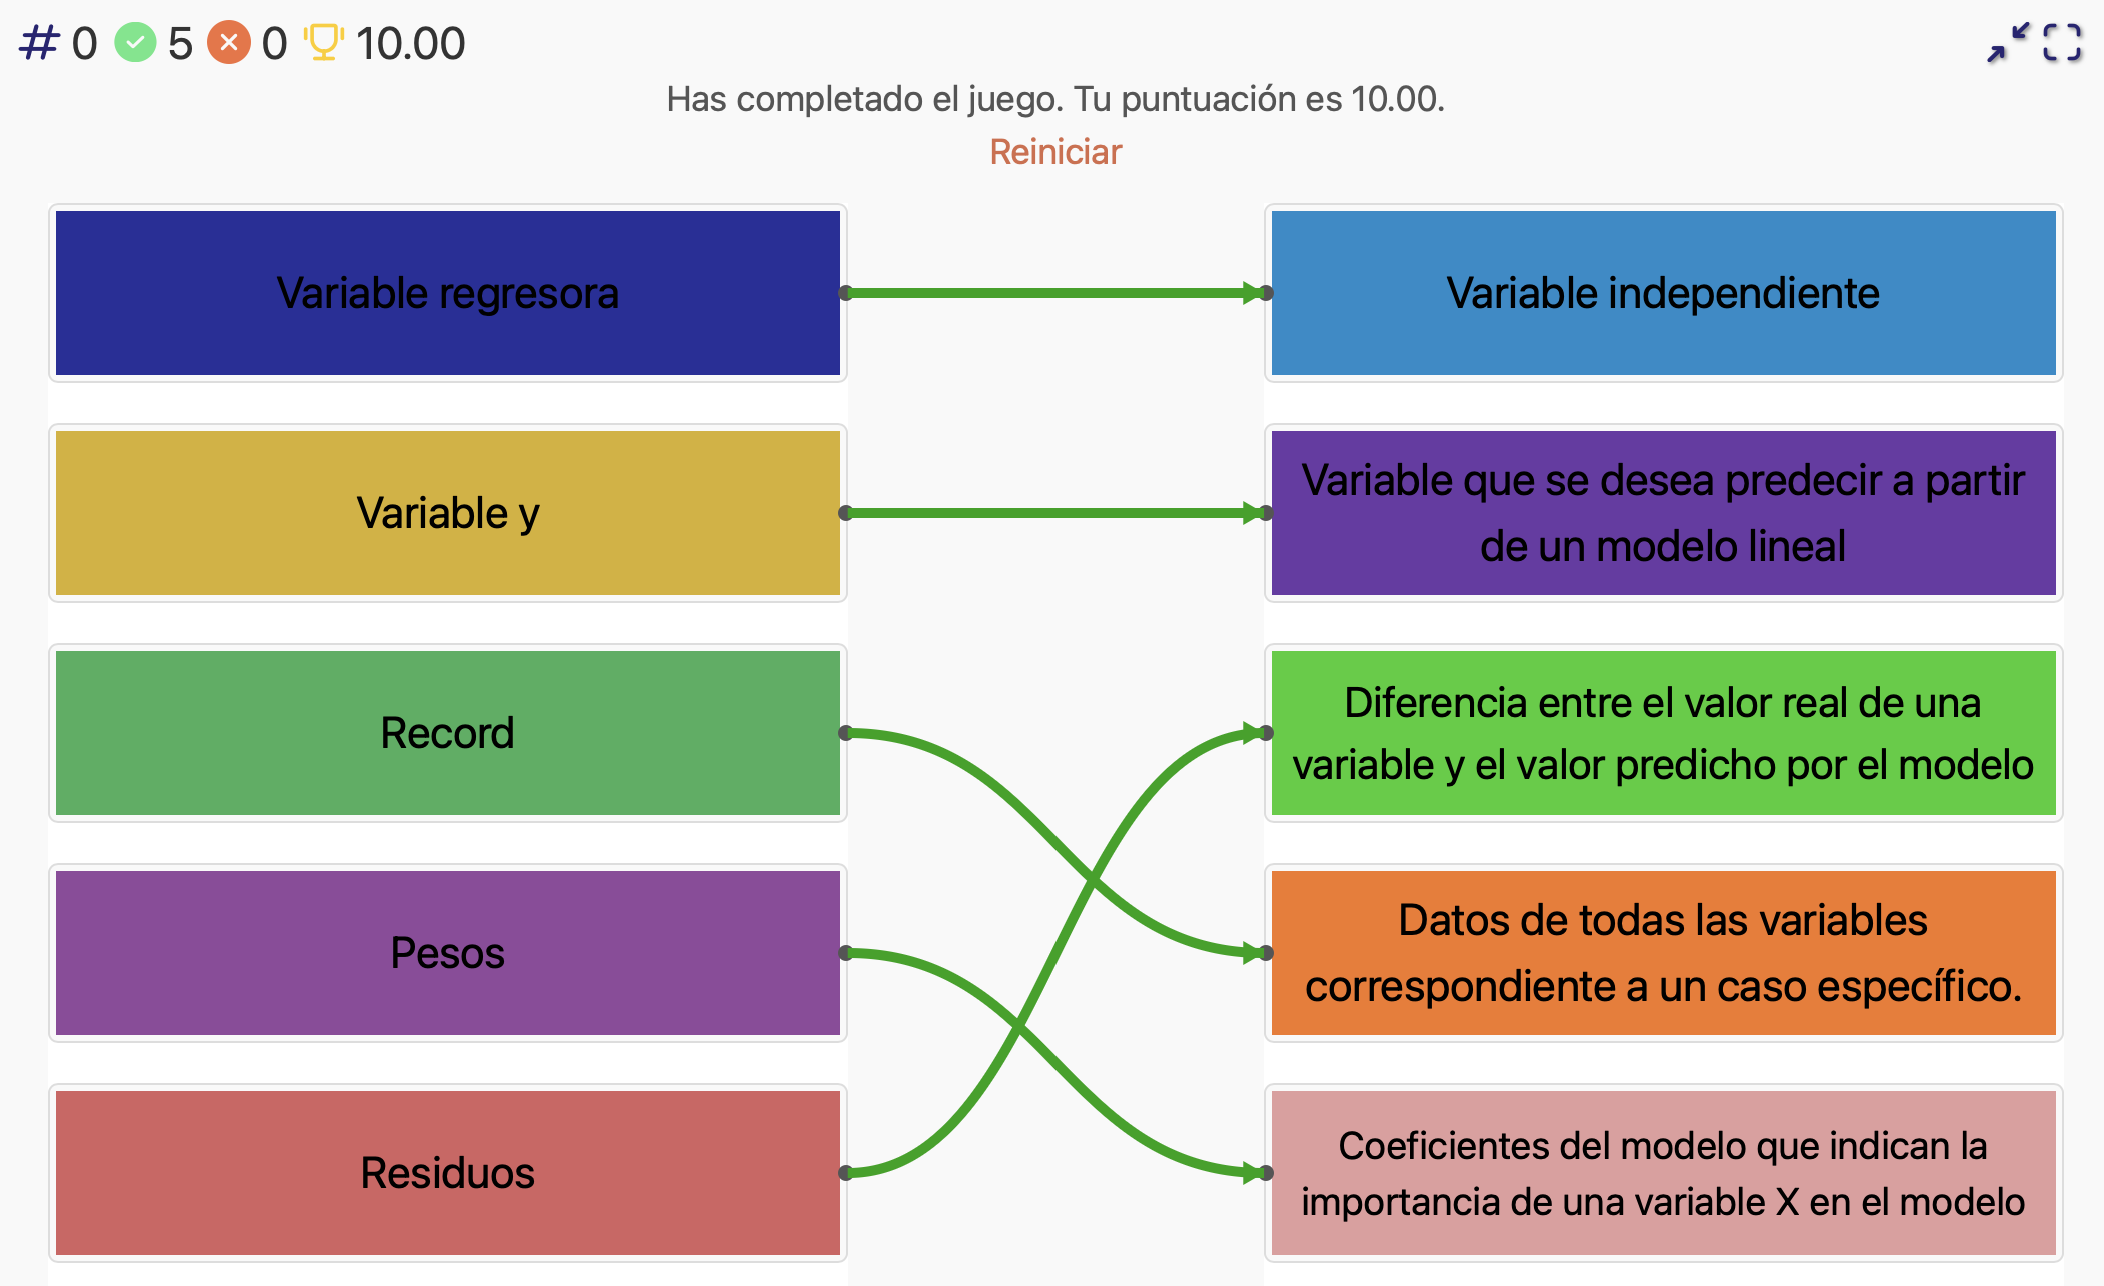

# Regresión Lineal Simple
En este caso los modelos cuentan con una única variable $X$ y son de la forma: 

$y=\beta_{0} + \beta_{1}X$

Es decir que la relación entre $X$ y $y$ está dada por una linea recta.

# Carga de datos

La obtención de celulosa a partir de subproductos agroindustriales como la cascarilla de café, requiere de un proceso de blanqueamiento de la materia prima. El desempeño de este proceso puede hacerse midiendo un índice blancura (WI, por sus siglas en inglés) con métodos como la colorimetría, pero se quiere establecer si es posible determinar ese valor de colorimetría a partir de una medición hecha con fotografía. 

Se cuenta con set de datos, donde $X$ es el índice blancura medido con fotografía, y $y$ el índice de blancura medido con colorimetría. 

In [24]:
import pandas as pd 

data = pd.read_excel("data_validación.xlsx")

X = data[['X']]

y = data["y"]

# Creación del Modelo

Con ayuda de la librería SciKit_learn, creamos y ajustamos el modelo. Esto nos dará unos parámetros:

- *__fit_intercept__*: Si calcular la intercepción para este modelo. Si se establece en Falso, no se utilizará ninguna intercepción en los cálculos (es decir, se espera que los datos se centren).

- *___copy_X___*: Si es verdadero, X se copiará; de lo contrario, puede sobrescribirse.

- *__tol__*: Este parámetro no tiene efecto cuando se ajusta a datos densos. Debido a que su valor es el predeterminado. (predeterminado=1e-6)

- *__n_jobs__*: El número de tareas que se utilizarán para el cálculo. Esto solo supondrá una aceleración en el caso de problemas suficientemente grandes, es decir:
    - Si en primer lugar, «n_targets > 1» y, en segundo lugar, «X» es un vector disperso o si es «positive» "n_jobs" se establece en «True». 
    - «None» significa 1, salvo en un contexto de «joblib.parallel_backend». 
    - -1 significa que se utilizarán todos los procesadores.

- *__positive__*: Cuando se establece en True, obliga a los coeficientes a ser positivos. Esta opción solo es compatible con matrices densas.

In [25]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression(fit_intercept=True) # se crea un objeto de la clase LinearRegression (Modelo)
modelo.fit(X,y) # luego se ajusta el objeto con el método fit() a los datos de interés

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Para este caso:
- *__fit_intercept__*: Se espera que los no se centren.

- *__copy_X__*:  X se copiará.

- *__tol__*: Este parámetro no tiene efecto.

- *__n_jobs__*: None, significa 1. Por lo tanto hay un trabajo a utilizar para el cálculo.

- *__positive__*: Los coeficientes no son obligados a ser positivos.

# Coeficiente del modelo

Teniendo en cuenta la forma de una regresión lineal de una sola variable, $y=\beta_{0} + \beta_{1}X$, hay que encontrar $\beta_{0}$ y $\beta_{1}$.

Luego, usar los coefeicientes para encontrar el valor de $y$ predicho por el modelo.

Los coeficientes del modelo son atributos del objeto "modelo" creado, $\beta_{0}$ está en el atributo intercept_ y  $\beta_{1}$ en el atributo coef_

In [36]:
import numpy as np


beta0 = modelo.intercept_ 
beta1 = modelo.coef_

x_plot = np.linspace(58,97,20) #rango de datos de un X para probar

y_plot = beta0 + beta1*x_plot #valor de "y" predichos por el modelo para los x_plot

# Graficar el Modelo
Grafiquemos los datos x_plot y y_plot generados antes, contra los datos originales. 

/var/folders/6g/6n30jc0j6jq8ktywt94l6q740000gn/T/ipykernel_28844/2014772499.py:6: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(X,y,c=[245/255, 149/255, 39/255],label="Datos reales")


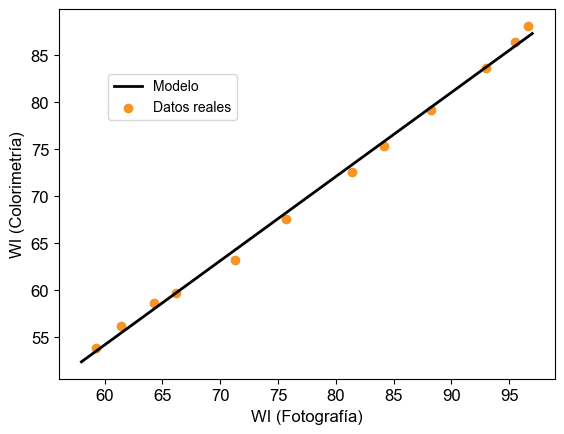

In [ ]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots()

ax.plot(x_plot,y_plot,c='k',lw=2, label="Modelo")# Rango de X y los datos para "y" predichos
ax.scatter(X,y,c=[245/255, 149/255, 39/255],label="Datos reales")# Datos reales medidos con colorimetría y fotografía

ax.set_ylabel("WI (Colorimetría)",fontname = "Arial",fontsize=12)
ax.set_xlabel("WI (Fotografía)", fontname="Arial",fontsize=12)

plt.xticks(fontfamily = "Arial",fontsize=12)
plt.yticks(fontfamily = "Arial",fontsize=12)
ax.legend(prop={'family':"Arial", 'size':10},loc=(0.1,0.7),fontsize=12)

Según la gráfica, se concluye que la relación que tienen el índice de blancura medido con fotografía y medido con colorimetría es similar en gran proporción. 

# Regresión lineal múltiple
Las variables dependientes requieren ser explicadas a partir de más de una variable independiente.

La forma del modelo depende si es de:

- *__Modelo de efectos principales__*:
    Se consideran solo el efecto de las variables independientes.

    $y=\beta_{0} + \beta_{1}X_{1} + \beta_{2}X_{2} + ... + \beta_{n}X_{n}$

- *__Modelo con interacciones__*:
    Se consideran las posibles interacciones multiplicativas entre las variables independientes. Por lo tanto, $y$ podría describirse no solo por una combinación lineal de las variables $X$, sino también por una combinación lineal de las variables  $X$ + combinaciones multiplicativas de orden  $n$ o inferior.

    *__Ejemplo__*

    Un modelo con 2 variables regresoras, con interacciones de orden 2 sería de la forma: 

    $y=\beta_{0} + \beta_{1}X_{1} + \beta_{2}X_{2} + \beta_{3}X_{1}X_{2}$

    Y un modelo con 3 variables regresoras con interacciones de orden 3 sería de la forma:

    $y=\beta_{0} + \beta_{1}X_{1} + \beta_{2}X_{2} + \beta_{3}X_{1} + \beta_{4}X_{1}X_{2} + \beta_{5}X_{2}X_{3} + \beta_{6}X_{1}X_{2}X_{3}$
    
    *__NOTA__*: El orden de interacciónes son los $\beta$ que se suman lusgo de que cada variable regresora ya tenga su propio $\beta$, es decir:

    El mismo modelo anterior, pero con interacciones de orden 2 sería de la forma:
        
    $y=\beta_{0} + \beta_{1}X_{1} + \beta_{2}X_{2} + \beta_{3}X_{1} + \beta_{4}X_{1}X_{2} + \beta_{5}X_{2}X_{3}$
# Carga de Datos

In [26]:
import pandas as pd

df = pd.read_excel('diabetes.xlsx')

# Análisis de correlación:
Permite realizar la selección de variables regresoras a partir de una matriz de correlación de datos.


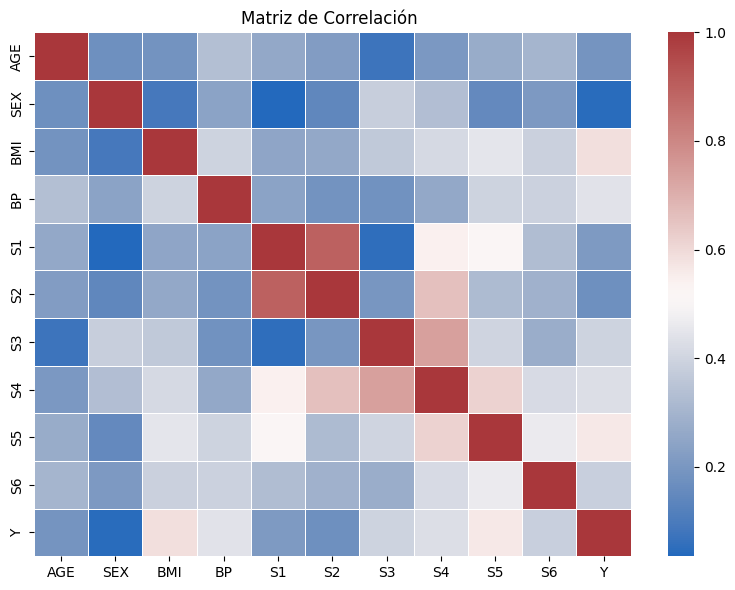

In [27]:
import seaborn as sns

corr_matrix = df.corr()

plt.figure(figsize=(8, 6))

plt.title("Matriz de Correlación ")

#no importa si la correlación es positiva o negativa, entonces se puede graficar abs
sns.heatmap(abs(corr_matrix.values), cmap='vlag', fmt=".2f", linewidths=0.5,xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)

plt.tight_layout()

Aquí se observa que, S1 y S4 son las variables que mejor correlación tienen con S2, por lo cual podrían ser útiles en un modelo de regresión lineal. 

# Modelo de efectos principales:
La construcción del modelo de efectos principales se logra de la misma forma que se hizo en en el modelo de regresión lineal simple:


In [28]:
y = df['S2']

X = df[['S1','S4']]

from sklearn.linear_model import LinearRegression

modelo = LinearRegression(fit_intercept=True).fit(X,y)

beta0 = modelo.intercept_ #intercepto

coef = modelo.coef_ #coeficientes
beta1 = coef[0]
beta2 = coef[1]
print(f"beta 1: {beta0}")
print(f"beta 1: {beta1}")
print(f"beta 2: {beta2}")


variables = modelo.feature_names_in_ #nombre de las variables de los coef
print(variables)

beta 1: -35.026267807223974
beta 1: 0.6707863279490702
beta 2: 5.796377729496523
['S1' 'S4']


Con esto el modelo sería:

$S_{2}= -35.02 + 0.67S_{1} + 5.8S_{4}$

/var/folders/6g/6n30jc0j6jq8ktywt94l6q740000gn/T/ipykernel_33813/3893250593.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(df['S1'], df['S4'], df['S2'],


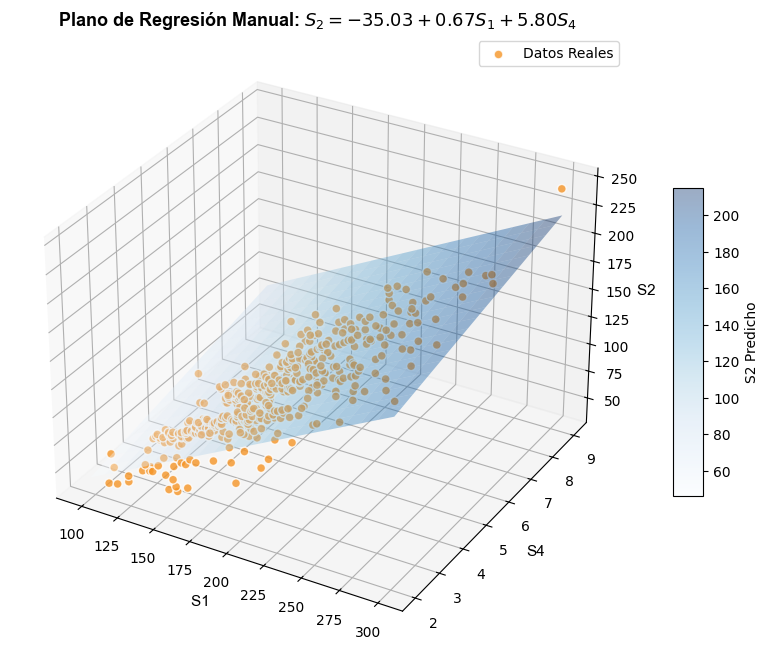

In [29]:
import matplotlib.pyplot as plt
import numpy as np


# Crear un rango de valores para S1 y S4 (los ejes de la base)
# Usamos 20 puntos en cada eje para crear una malla de 400 puntos en total
s1_range = np.linspace(df['S1'].min(), df['S1'].max(), 20)
s4_range = np.linspace(df['S4'].min(), df['S4'].max(), 20)

# Crear la malla (grid)
S1_grid, S4_grid = np.meshgrid(s1_range, s4_range)

# 3PREDICCIÓN MANUAL en 3D
# Aplicamos la ecuación directamente sobre la malla -> S_{2}= -35.02 + 0.67S_{1} + 5.8S_{4}
S2_predicho = beta0 + (beta1 * S1_grid) + (beta2 * S4_grid)

# Configurar la figura 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# --- Graficar DATOS REALES ---
# Usamos scatter para los puntos del DataFrame original
ax.scatter(df['S1'], df['S4'], df['S2'], 
           c=[245/255, 149/255, 39/255], 
           label='Datos Reales', 
           alpha=0.8, s=40, edgecolors='w')

# --- Graficar EL PLANO DEL MODELO ---
# El "plano" representa todas las predicciones posibles de la ecuación manual
superficie = ax.plot_surface(S1_grid, S4_grid, S2_predicho, 
                             alpha=0.4, 
                             cmap='Blues', 
                             edgecolor='none')

# Personalización y etiquetas
ax.set_xlabel('S1 ', fontname="Arial", fontsize=11)
ax.set_ylabel('S4', fontname="Arial", fontsize=11)
ax.set_zlabel('S2 ', fontname="Arial", fontsize=11)
ax.set_title(f'Plano de Regresión Manual: $S_2 = {beta0:.2f} + {beta1:.2f}S_1 + {beta2:.2f}S_4$', 
             fontname="Arial", fontsize=13, fontweight='bold')

# Añadir una barra de color para la altura del plano
fig.colorbar(superficie, ax=ax, shrink=0.5, aspect=10, label='S2 Predicho')

ax.legend()
plt.show()

# Modelo con interacciones 

Para realizar un modelo con interacciones debemos hacer un *__pipeline__* entre la clase _LinearRegression()_ y la clase _PolynomialFeatures()_, para encadenar una regresión múltiple de efectos principales, con sus interacciones, y ajustamos ese objeto a nuestros datos $X$ y $y$.


In [30]:
from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

y = df['S2']

X = df[['S1','S4']]

# El modelo tendrá interacciones de grado 2, y debemos tener en la clase PoynomialFeatures() el
#parámetro interction_only = True, para que solo incluya las interacciones, ya que esta 
#clase se usa para construir también modelos polinómicos, y de no estar en True este parámetro 
#el modelo incluiría potencias. 
modelo = make_pipeline(PolynomialFeatures(degree= 2, interaction_only=True),LinearRegression()).fit(X,y)

Para conocer los coeficientes del modelo, estos son atributos del objeto "modelo" creado y podemos acceder a ellos como se muestra a continuación. Asimismo, al tener varios regresores debemos conocer cada coeficiente a qué regresor corresponde, veamos:

In [31]:

beta0 = modelo._final_estimator.intercept_ 
coef = modelo._final_estimator.coef_
features = modelo.named_steps.polynomialfeatures.get_feature_names_out()

print(f"beta0: {beta0}")
o = len(coef)
u = 0
for i in coef:
    print(f"beta{u+1}: {i}")
    u = u+1
print(features)

beta0: -43.135164537781975
beta1: 0.0
beta2: 0.7124968109618508
beta3: 7.816328595219755
beta4: -0.010077904274951883
['1' 'S1' 'S4' 'S1 S4']


En estos casos, siempre el primer coeficiente será cero, puede ignorarse.

Así el modelo sería: 

$S_{1}= -43.14 + 0.71S_{1} + 0.82 S_{2}- 0.01S_{1}S_{2}$

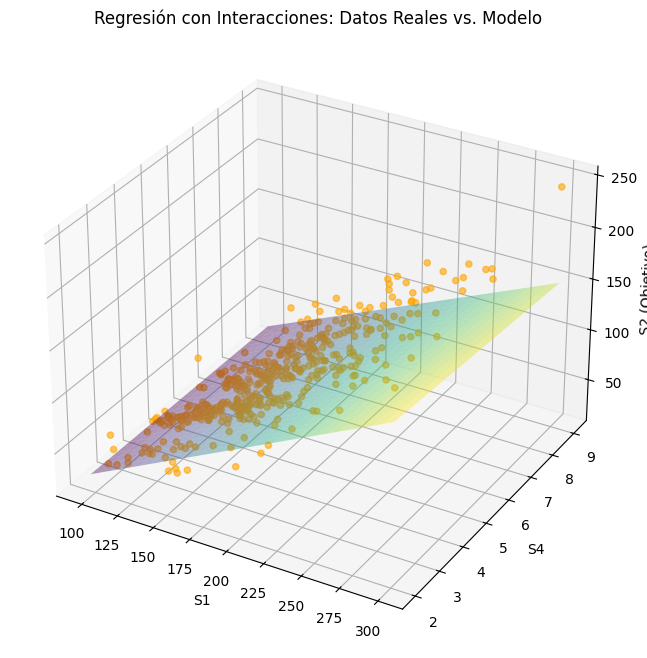

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Definir la función del modelo basada en tu fórmula
# S1_pred = -43.14 + 0.71*S1 + 0.82*S2 - 0.01*S1*S2
def modelo_interaccion(s1, s2):
    return -43.14 + (0.71 * s1) + (0.82 * s2) - (0.01 * s1 * s2)

# Crear una malla (grid) para la superficie del modelo
# Usamos el rango de los datos reales para que la gráfica coincida
s1_range = np.linspace(df['S1'].min(), df['S1'].max(), 30)
s2_range = np.linspace(df['S4'].min(), df['S4'].max(), 30) # Usando S4 como la segunda variable del código
S1_grid, S2_grid = np.meshgrid(s1_range, s2_range)
Y_pred_surface = modelo_interaccion(S1_grid, S2_grid)

# Configurar la gráfica 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar los DATOS REALES (Puntos)
ax.scatter(df['S1'], df['S4'], df['S2'], c='orange', label='Datos Reales', alpha=0.6)

# Graficar la SUPERFICIE DEL MODELO
surf = ax.plot_surface(S1_grid, S2_grid, Y_pred_surface, cmap='viridis', alpha=0.4)

# Etiquetas y leyenda
ax.set_xlabel('S1')
ax.set_ylabel('S4')
ax.set_zlabel('S2 (Objetivo)')
ax.set_title('Regresión con Interacciones: Datos Reales vs. Modelo')

plt.show()